In [87]:
import math
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [88]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#Уменьшил в два раза чтобы ускорить вычисления
image_gray = cv2.resize(image_gray, (0,0), fx=0.5, fy=0.5)

image = cv2.imread('altpalm.jpg')
image_pl = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray_pl = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def homo_average(img, mask, point, T):
    av_val = img[mask > 0].sum() / np.count_nonzero(img[mask > 0])                                                        
    if abs(av_val - img[point]) <= T:
        return True
    return False

def region_growing(image, seed_point, homo_fun, r, T):
    mask = np.zeros(image.shape, np.uint8)
    mask[seed_point] = 1
    count = 1
    while count > 0:
        count = 0
        local_mask = np.zeros(image.shape, np.uint8)
        for i in range(r, image.shape[0] - r):
            for j in range(r, image.shape[1] - r):
                if mask[i,j] == 0 and mask[i - r:i + r, j-r: j+r].sum() > 0:
                    if homo_fun(image, mask, (i,j), T):
                        local_mask[i,j] = 1
        count = np.count_nonzero(local_mask)
        print(count)
        mask += local_mask
    return mask * 255

***1. Подберите парамтеры алгоритма разрастания регионов так, чтобы был выделен весь участок газона.***

14
31
49
63
81
104
119
134
152
167
186
132
151
147
153
158
160
165
157
163
161
154
148
147
141
138
134
125
123
109
104
98
97
124
83
77
44
38
39
38
34
31
30
28
28
25
25
23
22
19
18
14
15
15
14
13
10
9
6
3
3
0


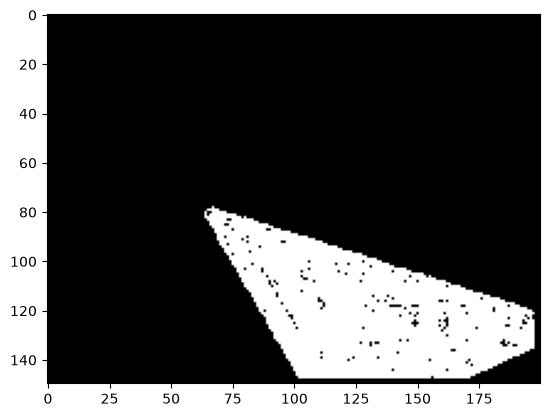

In [89]:
seed_point = (125, 125)
mask_lawn1 = region_growing(image_gray, seed_point, homo_average, 2, 15)

plt.imshow(mask_lawn1, cmap="gray")

56
155
248
346
438
364
396
412
367
337
316
280
248
247
290
227
209
159
127
112
91
98
109
118
103
115
128
129
152
178
161
168
220
204
198
172
169
224
209
206
185
4
0


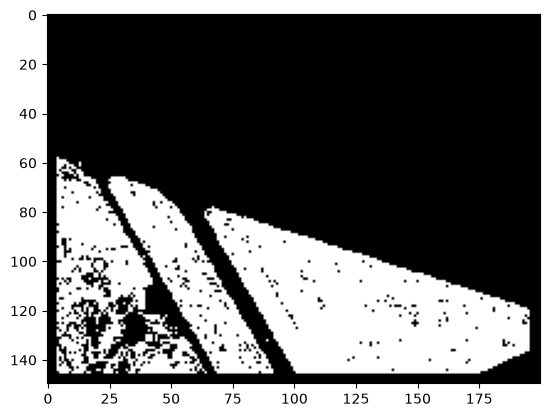

In [90]:
mask_lawn2 = region_growing(image_gray, seed_point, homo_average, 4, 15)

plt.imshow(mask_lawn2, cmap="gray")

61
161
258
355
454
380
417
408
384
352
332
306
301
331
369
385
388
394
403
406
409
421
474
520
548
553
402
421
394
427
400
405
464
476
445
471
497
497
451
477
322
138
116
108
143
158
140
126
260
127
105
136
132
97
88
85
93
102
91
46
31
25
18
0


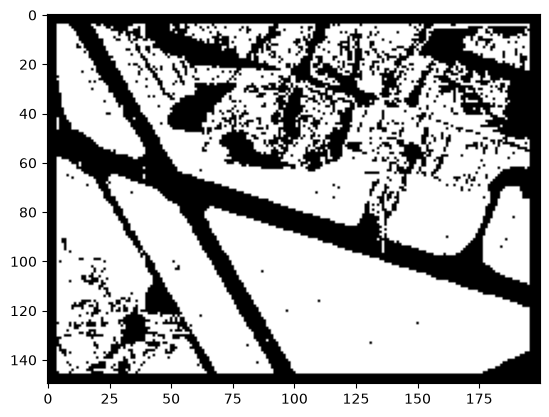

In [91]:
mask_lawn3 = region_growing(image_gray, seed_point, homo_average, 4, 22)

plt.imshow(mask_lawn3, cmap="gray")

***2. Реализуйте вычисление критерия однородности, отличного от представленного. Сравните результаты.***

**Сделан алгоритм, считающий макс разницу пикселей в регионе вместо сравнения со средним**

63
161
259
357
455
381
418
410
387
357
329
307
302
335
374
381
395
404
417
419
408
444
516
584
632
603
421
401
435
473
471
489
523
524
501
547
526
519
491
500
354
139
132
119
151
159
136
121
121
107
39
31
18
5
0


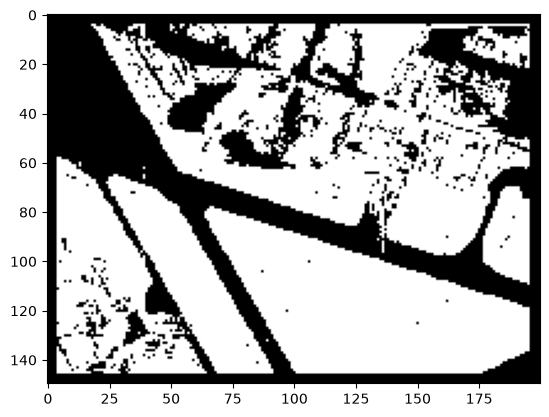

In [92]:
def homo_range(img, mask, point, T):
    region = img[mask > 0]
    new_min = min(int(region.min()), int(img[point]))
    new_max = max(int(region.max()), int(img[point]))
    if (new_max - new_min) <= T:
        return True
    return False

mask_range = region_growing(image_gray, seed_point, homo_range, 4, 60)
plt.imshow(mask_range, cmap="gray")
plt.show()

**Алгоритм хуже спраляется с градиентами, в данном случае он просто пропустил плавно затемненный участок газона слева сверху**

***3.Применить алгоритм сегментации watershed+distance transform для задачи подсчета***

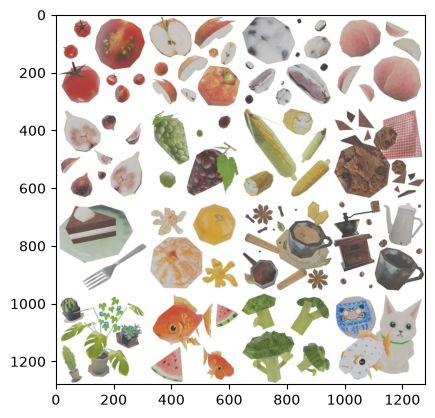

In [93]:
plt.imshow(image_pl)

Количество объектов: 123


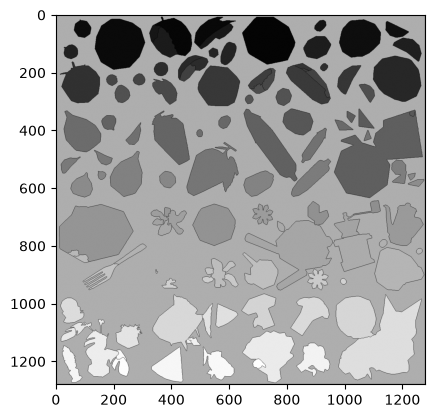

In [94]:
ret, thresh = cv2.threshold(image_gray_pl, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5) 

ret, sure_fg = cv2.threshold(dist, 0.1 * dist.max(), 255, cv2.THRESH_BINARY) 
sure_fg = sure_fg.astype(np.uint8)

ret, markers = cv2.connectedComponents(sure_fg) 

markers = cv2.watershed(image, markers)

palm_count = ret
print("Количество объектов:", palm_count)
plt.imshow(markers, cmap="gray")